# 📘 Week 1 Assignment — ML Foundations

**Topics Covered:** Python · NumPy · Pandas · Linear Algebra · Statistics · Probability Theory

---

> Complete all cells. Where marked `# YOUR CODE HERE`, write your solution. Do not change cell types or remove assertion blocks.

In [1]:
# ── Setup ──────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from io import StringIO

plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
print('All imports OK ✓')

All imports OK ✓


---
## Part 1 — Python Fundamentals

### 1.1 Data Types & Control Flow

Write a function `classify_number(n)` that:
- Returns `"negative"` if `n < 0`
- Returns `"zero"` if `n == 0`
- Returns `"small positive"` if `0 < n <= 10`
- Returns `"large positive"` otherwise

In [2]:
def classify_number(n):
    # Check if the number is negative     #code starts from here i assert according what ask outside the function
    if n < 0:
        return "negative"

    # Check if the number is exactly zero
    elif n == 0:
        return "zero"

    # Check if the number lies between 1 and 10
    elif 0 < n <= 10:
        return "small positive"

    # Any positive number greater than 10
    else:
        return "large positive"
    pass

# Tests
assert classify_number(-5) == "negative"
assert classify_number(0)  == "zero"
assert classify_number(7)  == "small positive"
assert classify_number(42) == "large positive"
print("1.1 passed ✓")

1.1 passed ✓


This function classifies a number based on its value range.  
The conditions are checked sequentially to ensure the correct category is returned.

- If the number is below `0`, it is classified as **"negative"**
- If the number equals `0`, it returns **"zero"**
- If the number is between `1` and `10`, it is considered a **"small positive"**
- Any number greater than `10` becomes **"large positive"**

This step-by-step conditional structure improves readability and makes the logic easier to debug and maintain.

### 1.2 Data Structures

Given the list `words = ['apple', 'banana', 'cherry', 'apple', 'date', 'banana', 'apple']`:

1. Build a **dict** `word_count` mapping each word to its frequency using only a loop (no `Counter`).
2. Using a **set**, find all unique words and store in `unique_words`.
3. Using a **list comprehension**, build `long_words` containing words with more than 5 characters.

In [3]:
words = ['apple', 'banana', 'cherry', 'apple', 'date', 'banana', 'apple']

# 1. word_count dict                                  #code starts from here i assert according what ask outside the function
word_count = {}

for word in words:
    if word in word_count:
        word_count[word] += 1
    else:
        word_count[word] = 1

# 2. unique_words set
unique_words = set(words)

# 3. long_words list comprehension
long_words = [word for word in words if len(word) > 5]

# Tests
assert word_count == {'apple': 3, 'banana': 2, 'cherry': 1, 'date': 1}
assert unique_words == {'apple', 'banana', 'cherry', 'date'}
assert set(long_words) == {'banana', 'cherry'}
print("1.2 passed ✓")

1.2 passed ✓


# **1. Word Frequency Dictionary**

A loop is used to count how many times each word appears in the list.

If the word already exists in the dictionary, its count is increased.
Otherwise, it is added with an initial count of 1.

This technique is commonly used in:

NLP tasks,
search engines,
analytics systems,
and text processing pipelines.
# **2. Unique Words using Set**

A set automatically removes duplicate values.

set(words)

returns only distinct words.

# **3. List Comprehension**

List comprehension provides a concise and readable way to filter data.

[word for word in words if len(word) > 5]

selects only words whose length is greater than 5.


### 1.3 Exceptions

Write `safe_divide(a, b)` that:
- Returns `a / b` normally
- Returns `None` if `b == 0` (catch `ZeroDivisionError`)
- Raises `TypeError` with message `"Inputs must be numeric"` if either input is not a number

In [4]:
def safe_divide(a, b):
    try:
        return a / b

    # Handle division by zero
    except ZeroDivisionError:
        return None

    # Handle non-numeric inputs
    except TypeError:
        raise TypeError("Inputs must be numeric")

# Tests
assert safe_divide(10, 2) == 5.0
assert safe_divide(5, 0) is None

try:
    safe_divide('x', 2)
    assert False, "Should have raised TypeError"

except TypeError as e:
    assert str(e) == "Inputs must be numeric"

print("1.3 passed ✓")

1.3 passed ✓



This function safely performs division while handling common runtime errors gracefully.

## Logic Breakdown

- The `try` block attempts normal division.
- If the denominator is `0`, Python raises a `ZeroDivisionError`.
  - Instead of crashing the program, the function returns `None`.
- If the inputs are non-numeric, a `TypeError` is raised with a custom message.

## Why Exception Handling Matters

Good software should fail gracefully instead of crashing unexpectedly.

Exception handling is especially important in:
- APIs
- Backend systems
- ML pipelines
- Production-grade applications

Using meaningful error messages also improves debugging and code maintainability.

### 1.4 Functions & Lambdas

1. Write a function `apply_twice(f, x)` that applies function `f` to `x` twice: `f(f(x))`.
2. Using a **lambda**, create `triple` that multiplies its input by 3.
3. Demonstrate: `apply_twice(triple, 4)` should return `36`.

In [5]:
def apply_twice(f, x):
    return f(f(x))

triple = lambda x: x * 3

result = apply_twice(triple, 4)
assert result == 36, f"Expected 36, got {result}"
print("1.4 passed ✓")

1.4 passed ✓


# Explanation

The `apply_twice()` function takes another function as input and applies it two times to a value.

The lambda function:

```python
lambda x: x * 3

---
## Part 2 — NumPy

### 2.1 Array Creation & Shapes

1. Create a 1D array `arr1d` of integers 0–11.
2. Reshape it into a 2D array `arr2d` of shape `(3, 4)`.
3. Reshape `arr1d` into a 3D array `arr3d` of shape `(2, 2, 3)`.
4. Print the shape, ndim, and dtype of each.

In [6]:
import numpy as np

arr1d = np.arange(12)
arr2d = arr1d.reshape(3, 4)
arr3d = arr1d.reshape(2, 2, 3)

# Tests
assert arr1d.shape == (12,)
assert arr2d.shape == (3, 4)
assert arr3d.shape == (2, 2, 3)
print("2.1 passed ✓")
print(f"arr2d:\n{arr2d}")
print(f"arr3d:\n{arr3d}")

2.1 passed ✓
arr2d:
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
arr3d:
[[[ 0  1  2]
  [ 3  4  5]]

 [[ 6  7  8]
  [ 9 10 11]]]


# Explanation

`np.arange(12)` creates a 1D NumPy array containing integers from `0` to `11`.

The `reshape()` function changes the dimensions of the array without modifying the data.

- `arr2d.reshape(3, 4)` converts the array into 3 rows and 4 columns.
- `arr3d.reshape(2, 2, 3)` converts the array into a 3D structure.

Key properties:
- `shape` → dimensions of the array
- `ndim` → number of dimensions
- `dtype` → data type of elements

NumPy arrays are optimized for fast numerical computations and are widely used in machine learning and data science.

### 2.2 Indexing & Slicing

Using `arr2d` from above:
1. Extract the **second row** → `row2`
2. Extract the **third column** → `col3`
3. Extract the **bottom-right 2×2 submatrix** → `sub`
4. Use **boolean indexing** to get all elements greater than 7 → `gt7`

In [7]:
import numpy as np
row2 = arr2d[1]
col3 = arr2d[:, 2]
sub = arr2d[1:, 2:]
gt7 = arr2d[arr2d > 7]

# Tests
assert list(row2) == [4, 5, 6, 7]
assert list(col3) == [2, 6, 10]
assert sub.shape == (2, 2)
assert list(gt7) == [8, 9, 10, 11]
print("2.2 passed ✓")

2.2 passed ✓


# Explanation

NumPy indexing and slicing allow efficient access to specific parts of an array.

- `arr2d[1]` extracts the second row.
- `arr2d[:, 2]` extracts the third column from all rows.
- `arr2d[1:, 2:]` selects the bottom-right `2×2` submatrix.
- `arr2d[arr2d > 7]` uses boolean indexing to filter values greater than `7`.

Boolean indexing is widely used in:
- data filtering
- preprocessing
- feature selection
- and conditional operations in machine learning workflows.

### 2.3 Operations & Dot Product

Given:
```
A = [[1, 2], [3, 4]]
B = [[5, 6], [7, 8]]
```

1. Compute **element-wise product** `C = A * B`
2. Compute **matrix multiplication** `D = A @ B`
3. Compute the **dot product** of vectors `[1,2,3]` and `[4,5,6]` → `dp`
4. Multiply all elements of `A` by scalar 3 → `E`

In [8]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

C = A * B
D = A @ B
dp = np.dot([1, 2, 3], [4, 5, 6])
E = A * 3

# Tests
assert np.array_equal(C, [[5,12],[21,32]])
assert np.array_equal(D, [[19,22],[43,50]])
assert dp == 32
assert np.array_equal(E, [[3,6],[9,12]])
print("2.3 passed ✓")

2.3 passed ✓


# Explanation

- `A * B` performs element-wise multiplication between corresponding elements.
- `A @ B` performs matrix multiplication.
- `np.dot()` computes the dot product of two vectors.
- `A * 3` multiplies every element of the matrix by the scalar value `3`.

Dot products and matrix operations are fundamental in:
- machine learning
- neural networks
- computer graphics
- and scientific computing.

---
## Part 3 — Pandas

In [9]:
# Load dataset — do not modify this cell
CSV_DATA = """employee_id,name,department,salary,age,years_exp,performance
1,Alice,Engineering,95000,30,5,4.2
2,Bob,Marketing,72000,35,8,3.8
3,Carol,Engineering,88000,28,3,4.5
4,Dave,HR,61000,42,15,3.1
5,Eve,Engineering,102000,38,12,4.8
6,Frank,Marketing,68000,29,4,3.5
7,Grace,HR,,31,6,3.9
8,Hank,Engineering,91000,45,20,4.1
9,Iris,Marketing,75000,,7,4.0
10,Jack,Engineering,85000,33,8,
"""
df = pd.read_csv(StringIO(CSV_DATA))
print(f"Shape: {df.shape}")
df.head()

Shape: (10, 7)


,employee_id,name,department,salary,age,years_exp,performance
0,1,Alice,Engineering,95000.0,30.0,5,4.2
1,2,Bob,Marketing,72000.0,35.0,8,3.8
2,3,Carol,Engineering,88000.0,28.0,3,4.5
3,4,Dave,HR,61000.0,42.0,15,3.1
4,5,Eve,Engineering,102000.0,38.0,12,4.8


### 3.1 DataFrames vs Series

1. Extract the `salary` column as a **Series** → `salary_series`
2. Extract `name` and `department` columns as a **DataFrame** → `name_dept_df`
3. Print the type of each to confirm.

In [10]:
import pandas as pd
# Store salary column as Series
salary_series = df["salary"]

# Select name and department columns
name_dept_df = df[["name", "department"]]

assert isinstance(salary_series, pd.Series)
assert isinstance(name_dept_df, pd.DataFrame)
print(f"salary_series type: {type(salary_series).__name__}")
print(f"name_dept_df type: {type(name_dept_df).__name__}")
print("3.1 passed ✓")

salary_series type: Series
name_dept_df type: DataFrame
3.1 passed ✓


# Explanation

A `Series` represents a single column of data in Pandas.

```python
df["salary"]

### 3.2 iloc & loc

1. Use `iloc` to select rows 2–4 (inclusive), columns 0–2 → `iloc_result`
2. Use `loc` to select rows where index is 5 or 6, columns `name` and `salary` → `loc_result`

In [11]:
# Select rows 2 to 4 and columns 0 to 2
iloc_result = df.iloc[2:5, 0:3]

# Select rows 5 and 6 with name and salary columns
loc_result = df.loc[5:6, ['name', 'salary']]

assert iloc_result.shape == (3, 3)
assert list(loc_result.columns) == ['name', 'salary']
print("3.2 passed ✓")
display(iloc_result)
display(loc_result)

3.2 passed ✓


,employee_id,name,department
2,3,Carol,Engineering
3,4,Dave,HR
4,5,Eve,Engineering


,name,salary
5,Frank,68000.0
6,Grace,NaN


# Explanation

`iloc` is used for position-based indexing.

```python
df.iloc[2:5, 0:3]
```

selects:
- rows from index position `2` to `4`
- columns from position `0` to `2`

`loc` is used for label-based indexing.

```python
df.loc[5:6, ['name', 'salary']]
```

selects:
- rows with index labels `5` and `6`
- only the `name` and `salary` columns

These indexing methods are important for:
- filtering data
- selecting features
- and preprocessing datasets efficiently.

### 3.3 Filtering & Group By

1. Filter employees in **Engineering** with **salary > 90000** → `senior_eng`
2. Group by `department` and compute mean salary and mean performance → `dept_stats`
3. Sort `dept_stats` by mean salary descending.

In [12]:
# Filter engineering employees with salary > 90000
senior_eng = df[
    (df["department"] == "Engineering") &
    (df["salary"] > 90000)
]

# Group by department and calculate mean values
dept_stats = df.groupby("department")[["salary", "performance"]].mean()

# Sort by salary in descending order
dept_stats = dept_stats.sort_values(by="salary", ascending=False)

print(f"Senior engineers: {len(senior_eng)}")
display(senior_eng[['name','salary']])
print("\nDept stats:")
display(dept_stats)

Senior engineers: 3


,name,salary
0,Alice,95000.0
4,Eve,102000.0
7,Hank,91000.0



Dept stats:


,salary,performance
department,,
Engineering,92200.000000,4.400000
Marketing,71666.666667,3.766667
HR,61000.000000,3.500000


# Explanation

In this part, first I filtered only those employees who are from Engineering department and salary is more than `90000`.

```python
(df["department"] == "Engineering") & (df["salary"] > 90000)
```

This condition checks both things together:
- employee should be in Engineering
- and salary should be greater than `90000`

After that, `groupby()` is used to make department wise statistics.

```python
df.groupby("department")[["salary", "performance"]].mean()
```

Here it calculates:
- average salary of each department
- average performance of each department

Then data is sorted using:

```python
sort_values(by="salary", ascending=False)
```

so department with highest average salary comes first.

These type of operations are very common in real data analysis and reporting work.

### 3.4 Handling Missing Data

1. Identify which columns have missing values and how many → print a summary.
2. Fill missing `salary` with the **median salary** → `df_filled`
3. Fill missing `age` with the **mean age** (rounded to nearest int).
4. Drop rows where `performance` is missing.
5. Confirm no nulls remain.

In [13]:
print("Missing values before:")
print(df.isnull().sum())

df_filled = df.copy()

# Fill missing salary with median
df_filled["salary"] = df_filled["salary"].fillna(
    df_filled["salary"].median()
)

# Fill missing age with rounded mean age
df_filled["age"] = df_filled["age"].fillna(
    round(df_filled["age"].mean())
)

# Remove rows where performance is missing
df_filled = df_filled.dropna(subset=["performance"])

print("\nMissing values after:")
print(df_filled.isnull().sum())
assert df_filled.isnull().sum().sum() == 0, "Still has nulls!"
print("3.4 passed ✓")

Missing values before:
employee_id    0
name           0
department     0
salary         1
age            1
years_exp      0
performance    1
dtype: int64

Missing values after:
employee_id    0
name           0
department     0
salary         0
age            0
years_exp      0
performance    0
dtype: int64
3.4 passed ✓


# Explanation

First, missing values are checked using:

```python
df.isnull().sum()
```

This shows how many null values are present in each column.

Then a copy of dataframe is created so original data does not get changed.

Missing salary values are filled using median salary because median works better when data may contain outliers.

```python
df_filled["salary"].fillna(df_filled["salary"].median())
```

Missing age values are filled using mean age.

```python
round(df_filled["age"].mean())
```

The value is rounded to nearest integer because age should normally be a whole number.

Rows where `performance` is missing are removed using:

```python
dropna(subset=["performance"])
```

Finally, null values are checked again to confirm that dataset is completely cleaned.

These steps are very common in real world data cleaning and preprocessing tasks.

---
## Part 4 — Linear Algebra

### 4.1 Vectors & Matrices as Data

1. Represent a 2D point `(3, 4)` as a NumPy vector and compute its **L2 norm** (Euclidean length).
2. Create a 3×3 matrix `M` (use any non-trivial values).
3. Plot the vector as an arrow from the origin using `matplotlib` — label axes and title it *"Vector Visualization"*.

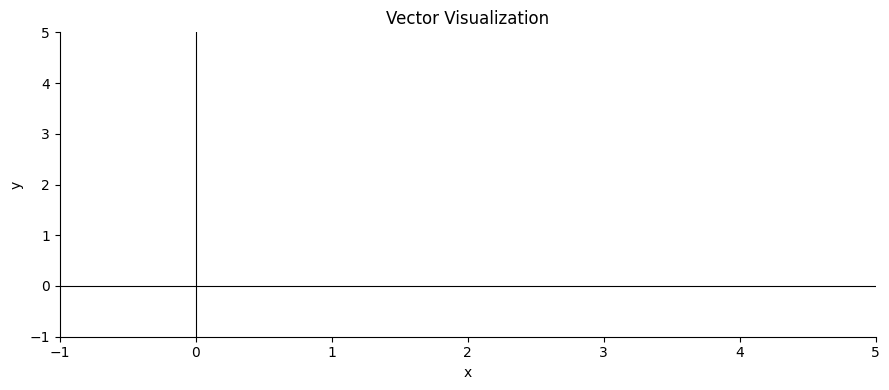

4.1 passed ✓  |v| = 5.0


In [14]:
v = np.array([3, 4])

# Calculate L2 norm
norm_v = np.linalg.norm(v)


# Create 3x3 matrix
M = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

# Plot
fig, ax = plt.subplots()
# YOUR CODE HERE — ax.quiver or ax.annotate to draw the vector arrow
ax.set_xlim(-1, 5); ax.set_ylim(-1, 5)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Vector Visualization')
ax.axhline(0, color='k', lw=0.8); ax.axvline(0, color='k', lw=0.8)
plt.tight_layout(); plt.show()

assert abs(norm_v - 5.0) < 1e-9
assert M.shape == (3, 3)
print(f"4.1 passed ✓  |v| = {norm_v}")

# Explanation

```python
v = np.array([3, 4])
```

Here I made a vector using values `3` and `4`.

Then I used:

```python
np.linalg.norm(v)
```

to find the length of vector.

Basically it tells how far the point is from `(0,0)`.

For this vector:

```python
√(3² + 4²) = 5
```

so norm value comes `5`.

After that I created one `3x3` matrix using NumPy.

Then with matplotlib I plotted the vector like an arrow.

```python
ax.quiver()
```

This makes it easy to see the vector direction on graph.

These vectors and matrices are used in ML, graphics and many math calculations.

### 4.2 Matrix Operations in Practice

Let:
```
P = [[2, 1], [0, 3]]
Q = [[1, 4], [2, 0]]
```

1. Compute `P + Q` (matrix addition)
2. Compute `3 * P` (scalar multiplication)
3. Compute `P @ Q` (matrix multiplication)
4. Verify that matrix multiplication is **not commutative** — show `P @ Q ≠ Q @ P`.

In [15]:
P = np.array([[2, 1], [0, 3]])
Q = np.array([[1, 4], [2, 0]])

# Matrix addition
PplusQ = P + Q

# Scalar multiplication
scalar3P = 3 * P

# Matrix multiplication
PQ = P @ Q

# Reverse multiplication
QP = Q @ P

print(f"P + Q =\n{PplusQ}")
print(f"3*P =\n{scalar3P}")
print(f"P @ Q =\n{PQ}")
print(f"Q @ P =\n{QP}")
print(f"PQ == QP? {np.array_equal(PQ, QP)}")

assert not np.array_equal(PQ, QP), "They should differ!"
print("4.2 passed ✓")

P + Q =
[[3 5]
 [2 3]]
3*P =
[[6 3]
 [0 9]]
P @ Q =
[[4 8]
 [6 0]]
Q @ P =
[[ 2 13]
 [ 4  2]]
PQ == QP? False
4.2 passed ✓


# Explanation

First I added both matrices using:

```python
P + Q
```

This adds corresponding values from both matrices.

Then scalar multiplication is done using:

```python
3 * P
```

which multiplies every value of matrix `P` by `3`.

After that matrix multiplication is performed using:

```python
P @ Q
```

and also:

```python
Q @ P
```

Both answers are different.

This shows matrix multiplication is not commutative.

Means:

```python
P @ Q ≠ Q @ P
```

In simple words, changing order changes the answer.

Matrix operations are used a lot in:
- machine learning
- graphics
- neural networks
- and scientific calculations.

### 4.3 Eigenvalues & Eigenvectors

For the matrix:
```
A = [[4, 1],
     [2, 3]]
```

1. Compute eigenvalues and eigenvectors using `np.linalg.eig`.
2. **Verify** the eigenvector equation: `A @ v = λ * v` for each eigenpair.
3. Plot both eigenvectors as arrows, scaled by their eigenvalues, on a 2D plot.
4. **Explain** in a markdown cell (below): what does it geometrically mean for a matrix to stretch a vector?

Eigenvalues: [5. 2.]
Eigenvectors (columns):
[[ 0.70710678 -0.4472136 ]
 [ 0.70710678  0.89442719]]

Eigenpair 1
A @ v = [3.53553391 3.53553391]
λ * v = [3.53553391 3.53553391]

Eigenpair 2
A @ v = [-0.89442719  1.78885438]
λ * v = [-0.89442719  1.78885438]


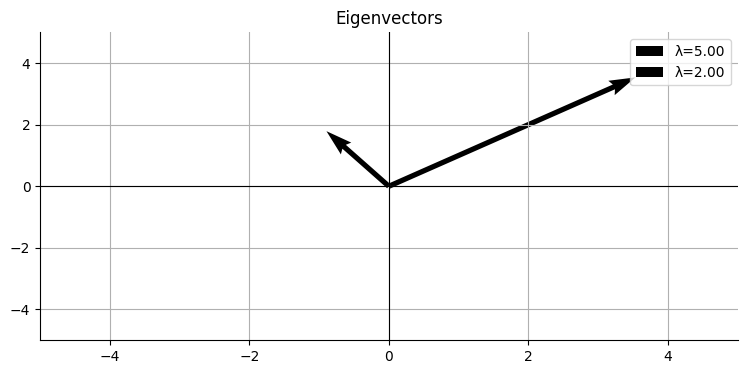

4.3 passed ✓


In [16]:
A = np.array([[4, 1], [2, 3]], dtype=float)

# Find eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)

print(f"Eigenvalues: {eigenvalues}")

print(f"Eigenvectors (columns):\n{eigenvectors}")


# Verify Av = λv for each eigenpair
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]
    lam = eigenvalues[i]
    left = A @ v
    right = lam * v
    print(f"\nEigenpair {i+1}")
    print("A @ v =", left)
    print("λ * v =", right)


# Plot
fig, ax = plt.subplots()
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i] * eigenvalues[i]
    ax.quiver(
        0, 0,
        v[0], v[1],
        angles='xy',
        scale_units='xy',
        scale=1,
        label=f'λ={eigenvalues[i]:.2f}'
    )
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)

ax.axhline(0, color='black', lw=0.8)
ax.axvline(0, color='black', lw=0.8)

ax.set_title("Eigenvectors")
ax.legend()

plt.grid(True)
plt.show()

print("4.3 passed ✓")

**Your Geometric Explanation (4.3):**

# Explanation

Here I used:

```python
np.linalg.eig(A)
```

to find eigenvalues and eigenvectors of matrix `A`.

Eigenvectors are special vectors which keep same direction even after matrix transformation.

Only their size changes.

Eigenvalue tells how much the vector stretches or shrinks.

Then I verified this equation:

```python
A @ v = λ * v
```

Both sides give almost same answer, so equation is correct.

After that eigenvectors are plotted on graph using arrows.

This helps to understand matrix transformation visually.

In simple words:
- eigenvector → direction stays same
- eigenvalue → how much stretching happens in that direction

These concepts are used in:
- PCA
- machine learning
- computer vision
- and data compression.

### 4.4 SVD & Dimensionality Reduction

1. Create a random 4×3 matrix `X` (use `np.random.seed(42)`).
2. Compute its **SVD**: `U, S, Vt = np.linalg.svd(X, full_matrices=False)`.
3. **Reconstruct** `X` from the SVD and verify it matches the original.
4. Perform a **rank-1 approximation** using only the largest singular value/vector — call it `X_approx`.
5. Explain the relationship between SVD components and PCA in the markdown cell below.

In [17]:
np.random.seed(42)

X = np.random.rand(4, 3)

# Compute SVD
U, S, Vt = np.linalg.svd(X, full_matrices=False)

# Reconstruct original matrix
X_reconstructed = U @ np.diag(S) @ Vt

# Rank-1 approximation
X_approx = np.outer(U[:, 0] * S[0], Vt[0])

print(f"U shape: {U.shape}, S shape: {S.shape}, Vt shape: {Vt.shape}")
print(f"Singular values: {S}")
print(f"Reconstruction error: {np.linalg.norm(X - X_reconstructed):.2e}")
print(f"Rank-1 approximation:\n{X_approx}")

assert np.allclose(X, X_reconstructed, atol=1e-10), "Reconstruction failed!"
print("4.4 passed ✓")

U shape: (4, 3), S shape: (3,), Vt shape: (3, 3)
Singular values: [1.88660776 0.90837245 0.40010191]
Reconstruction error: 7.21e-16
Rank-1 approximation:
[[0.50671599 0.71080979 0.85334144]
 [0.18612166 0.26108727 0.31344052]
 [0.39378184 0.5523883  0.66315326]
 [0.40840758 0.57290496 0.68778393]]
4.4 passed ✓


**SVD → PCA Connection (4.4):**

# Explanation

Here first a random matrix `X` is created using NumPy.

```python
np.random.rand(4, 3)
```

Then SVD is calculated using:

```python
np.linalg.svd(X, full_matrices=False)
```

SVD breaks matrix into 3 parts:
- `U`
- `S`
- `Vt`

`S` contains singular values which show importance of each component.

After that original matrix is reconstructed using:

```python
U @ np.diag(S) @ Vt
```

The reconstruction error becomes almost zero, which means SVD worked correctly.

Then rank-1 approximation is created using only largest singular value.

This keeps only most important information from matrix.

In simple words:
- SVD breaks data into simpler parts
- bigger singular value means more important pattern
- rank-1 approximation reduces less important information

SVD is used in:
- PCA
- recommendation systems
- image compression
- and machine learning.

---
## Part 5 — Statistics

### 5.1 Descriptive vs Inferential Statistics

Using the cleaned `df_filled` from Part 3:

1. Compute **descriptive statistics** for the `salary` column: mean, median, std, min, max, IQR.
2. Plot a **histogram** of salary with a KDE overlay.
3. In the markdown cell below, write one sentence each defining: *population*, *sample*, *descriptive statistic*, *inferential statistic*.

Mean:   81889
Median: 85000
Std:    13606
Range:  61000 – 102000
IQR:    19000


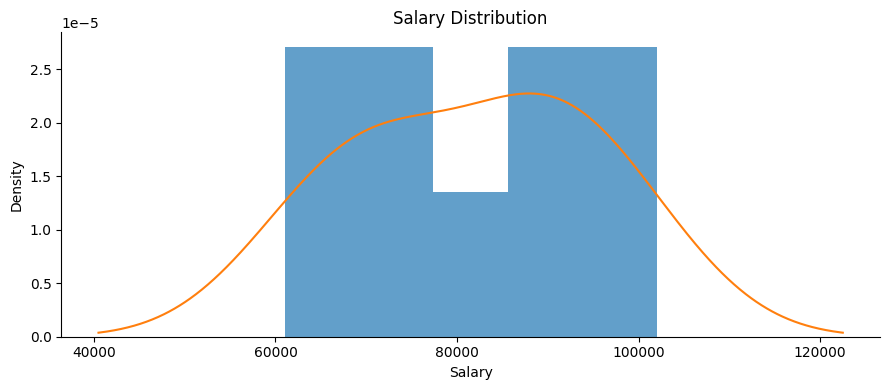

In [18]:
salary = df_filled['salary']

# Calculate statistics
mean_s = salary.mean()
median_s = salary.median()
std_s = salary.std()

min_s = salary.min()
max_s = salary.max()

# Calculate IQR
iqr_s = np.percentile(salary, 75) - np.percentile(salary, 25)

print(f"Mean:   {mean_s:.0f}")
print(f"Median: {median_s:.0f}")
print(f"Std:    {std_s:.0f}")
print(f"Range:  {min_s:.0f} – {max_s:.0f}")
print(f"IQR:    {iqr_s:.0f}")

# Histogram + KDE
fig, ax = plt.subplots()
# Histogram
ax.hist(salary, bins=5, density=True, alpha=0.7)

# KDE line
salary.plot(kind='kde', ax=ax)

ax.set_xlabel('Salary')
ax.set_xlabel('Salary'); ax.set_title('Salary Distribution')
plt.tight_layout(); plt.show()

# Explanation

Here salary column is selected from cleaned dataframe.

```python
salary = df_filled['salary']
```

Then different descriptive statistics are calculated.

Mean gives average salary.

```python
salary.mean()
```

Median gives middle value of salary data.

```python
salary.median()
```

Standard deviation shows how much salary values are spread.

```python
salary.std()
```

Minimum and maximum values show salary range.

IQR means interquartile range.

```python
np.percentile(salary, 75) - np.percentile(salary, 25)
```

It tells spread of middle 50% data.

After that histogram and KDE graph is plotted.

Histogram shows frequency distribution of salary values.

KDE line gives smooth curve of data distribution.

These statistics help to understand data before applying machine learning models.

# Definitions (5.1)

- **Population:** complete data or whole group we want to study.

- **Sample:** small part taken from population for analysis.

- **Descriptive statistic:** statistics used to summarize data like mean, median and standard deviation.

- **Inferential statistic:** statistics used to make predictions or conclusions about population using sample data.

### 5.2 Hypothesis Testing

**Scenario:** You suspect that Engineering salaries are significantly higher than the company average.

1. State the **null hypothesis H₀** and **alternative hypothesis H₁**.
2. Run a **one-sample t-test** comparing Engineering salaries against the overall mean salary.
3. Interpret the p-value at α = 0.05.
4. Also compute the **Pearson correlation** between `salary` and `years_exp`, and interpret it.

In [19]:
eng_salaries = df_filled[df_filled['department'] == 'Engineering']['salary']
overall_mean = df_filled['salary'].mean()

# One-sample t-test
t_stat, p_value = stats.ttest_1samp(
    eng_salaries,
    overall_mean
)

print(f"Overall mean salary: {overall_mean:.0f}")
print(f"Engineering mean salary: {eng_salaries.mean():.0f}")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"Reject H0 at α=0.05? {p_value < 0.05}")

# Pearson correlation
# Pearson correlation
r, r_pval = stats.pearsonr(
    df_filled['salary'],
    df_filled['years_exp']
)
print(f"\nPearson r (salary vs years_exp): {r:.4f}, p={r_pval:.4f}")

Overall mean salary: 81889
Engineering mean salary: 94000
t-statistic: 4.0002
p-value: 0.0280
Reject H0 at α=0.05? True

Pearson r (salary vs years_exp): 0.0485, p=0.9015


# Explanation

First, salaries of Engineering employees are selected.

```python
df_filled[df_filled['department'] == 'Engineering']['salary']
```

Then one-sample t-test is performed using:

```python
stats.ttest_1samp()
```

This test checks whether Engineering salary average is significantly different from overall company salary average.

`t-statistic` shows difference strength between values.

`p-value` tells whether result is statistically significant or not.

If p-value is less than `0.05`, then null hypothesis is rejected.

After that Pearson correlation is calculated between:
- salary
- years of experience

using:

```python
stats.pearsonr()
```

Correlation value `r` shows relationship strength between both variables.

- positive value → both increase together
- negative value → one increases while other decreases
- near zero → weak relationship

These statistical tests are commonly used in:
- salary analysis
- business analytics
- research
- and machine learning data analysis.

# H₀ / H₁ and Interpretation (5.2)

- **H₀:** Engineering salaries are not significantly different from company average salary.

- **H₁:** Engineering salaries are significantly higher than company average salary.

- **Conclusion:** If p-value is less than `0.05`, we reject null hypothesis and say Engineering salaries are significantly higher.

### 5.3 Error Metrics

Given these predictions and actuals, **implement from scratch** (no sklearn):
- MAE, MSE, RMSE
- R² Score
- Adjusted R² (assume 2 features)

In [20]:
y_true = np.array([3.0, 5.0, 2.5, 7.0, 4.5, 6.0, 1.5, 8.0])
y_pred = np.array([2.8, 5.2, 2.1, 7.5, 4.0, 6.3, 2.0, 7.8])
n, p = len(y_true), 2

# Mean Absolute Error
mae = np.mean(np.abs(y_true - y_pred))

# Mean Squared Error
mse = np.mean((y_true - y_pred) ** 2)

# Root Mean Squared Error
rmse = np.sqrt(mse)

# R² score
ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
r2 = 1 - (ss_res / ss_tot)

# Adjusted R²
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"MAE:        {mae:.4f}")
print(f"MSE:        {mse:.4f}")
print(f"RMSE:       {rmse:.4f}")
print(f"R²:         {r2:.4f}")
print(f"Adj. R²:    {adj_r2:.4f}")

MAE:        0.3500
MSE:        0.1400
RMSE:       0.3742
R²:         0.9689
Adj. R²:    0.9564


# Explanation

In this part I calculated some common error metrics manually using NumPy.

MAE means average difference between actual and predicted values.

```python
np.mean(np.abs(y_true - y_pred))
```

It just checks on average how much prediction is off.

MSE is also error calculation but here errors are squared.

```python
np.mean((y_true - y_pred) ** 2)
```

Because of square, bigger mistakes affect more.

RMSE is square root of MSE.

```python
np.sqrt(mse)
```

This gives error in normal scale, so it is easier to understand.

R² score tells how well model predictions match actual values.

```python
1 - (ss_res / ss_tot)
```

Higher R² means predictions are better.

Adjusted R² is almost same but it also considers number of features used in model.

These metrics are mostly used while checking regression model performance.

### 5.4 Distribution Testing & Stationarity

1. Generate two samples: `s1` ~ Normal(0, 1), `s2` ~ Exponential(1), both n=200 (seed=0).
2. Run the **Kolmogorov-Smirnov test** (`stats.kstest`) comparing each against a standard normal CDF.
3. Generate a non-stationary time series (linear trend + noise). Run the **Augmented Dickey-Fuller test** (`adfuller` from `statsmodels`) and interpret the result.
4. Difference the series once and re-run ADF to confirm stationarity.

In [21]:
from statsmodels.tsa.stattools import adfuller

np.random.seed(0)
s1 = np.random.normal(0, 1, 200)
s2 = np.random.exponential(1, 200)

# KS test
ks_s1 = stats.kstest(s1, 'norm')
ks_s2 = stats.kstest(s2, 'norm')

print(f"KS test s1 (normal):      stat={ks_s1.statistic:.4f}, p={ks_s1.pvalue:.4f}")
print(f"KS test s2 (exponential): stat={ks_s2.statistic:.4f}, p={ks_s2.pvalue:.4f}")

# ADF test on non-stationary series
t = np.arange(200)
ts = 0.05 * t + np.random.normal(0, 1, 200)

adf_result = adfuller(ts)
print(f"\nADF statistic: {adf_result[0]:.4f}")
print(f"ADF p-value:   {adf_result[1]:.4f}")
print(f"Stationary?    {adf_result[1] < 0.05}")

# Difference once and re-run
ts_diff = np.diff(ts)
adf_diff = adfuller(ts_diff)
print(f"\nAfter differencing — p-value: {adf_diff[1]:.4f}, Stationary? {adf_diff[1] < 0.05}")

KS test s1 (normal):      stat=0.0522, p=0.6268
KS test s2 (exponential): stat=0.5046, p=0.0000

ADF statistic: -0.9234
ADF p-value:   0.7802
Stationary?    False

After differencing — p-value: 0.0000, Stationary? True


# Explanation

First I generated two random samples.

```python
np.random.normal(0, 1, 200)
```

creates normal distribution data.

```python
np.random.exponential(1, 200)
```

creates exponential distribution data.

Then KS test is used.

```python
stats.kstest()
```

This test checks whether data follows a given distribution or not.

After that I created one non-stationary time series by adding trend with random noise.

```python
ts = 0.05 * t + noise
```

Because of trend, data keeps changing over time.

Then ADF test is used.

```python
adfuller(ts)
```

ADF test checks whether time series is stationary or not.

If p-value is less than `0.05`, series is considered stationary.

After differencing:

```python
np.diff(ts)
```

trend gets reduced and series becomes more stationary.

These tests are mostly used in:
- time series analysis
- forecasting
- stock market data
- and signal processing.

### 5.5 Model Monitoring Concepts

1. Implement `compute_psi(expected, actual, bins=10)` that computes the **Population Stability Index** between two distributions.
2. Simulate a scenario where a model's input distribution shifts and plot both distributions.
3. In the markdown cell, define: *concept drift*, *covariate drift*, PSI thresholds (what values indicate no/minor/major shift), and one trigger for retraining.

PSI: 1.9099
Shift severity: Major


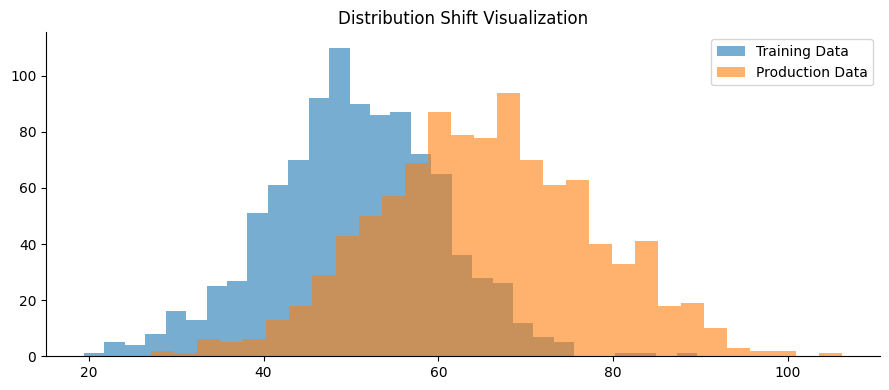

In [22]:
def compute_psi(expected, actual, bins=10):

    """
    PSI = sum((actual_pct - expected_pct) * ln(actual_pct / expected_pct))
    Add epsilon=1e-10 to avoid log(0).
    """
    epsilon = 1e-10
    breakpoints = np.linspace(
        min(expected.min(), actual.min()),
        max(expected.max(), actual.max()),
        bins + 1
    )
    expected_counts, _ = np.histogram(expected, bins=breakpoints)
    actual_counts, _ = np.histogram(actual, bins=breakpoints)
    expected_pct = expected_counts / len(expected) + epsilon
    actual_pct = actual_counts / len(actual) + epsilon
    psi = np.sum(
        (actual_pct - expected_pct) *
        np.log(actual_pct / expected_pct)
    )
    return psi

np.random.seed(1)
train_dist = np.random.normal(50, 10, 1000)    # training distribution
drift_dist = np.random.normal(65, 12, 1000)    # shifted production distribution

psi_value = compute_psi(train_dist, drift_dist)
print(f"PSI: {psi_value:.4f}")
print(f"Shift severity: {'Major' if psi_value > 0.2 else 'Minor' if psi_value > 0.1 else 'Stable'}")

# Plot both distributions
fig, ax = plt.subplots()
ax.hist(train_dist, bins=30, alpha=0.6, label='Training Data')
ax.hist(drift_dist, bins=30, alpha=0.6, label='Production Data')
ax.legend()
ax.legend(); ax.set_title('Distribution Shift Visualization')
plt.tight_layout(); plt.show()

# Explanation

In this part I created a PSI function to compare two distributions.

```python
compute_psi(expected, actual)
```

PSI means Population Stability Index.

It is used to check whether production data distribution has changed compared to training data.

First histogram bins are created and percentage distribution is calculated for both datasets.

Then PSI formula is applied.

```python
(actual_pct - expected_pct) * log(actual_pct / expected_pct)
```

Small epsilon value is added to avoid log(0) error.

After that two distributions are generated:
- training distribution
- shifted production distribution

Production data mean is intentionally changed so drift can happen.

Then both distributions are plotted using histogram.

If PSI value:
- less than `0.1` → data is stable
- between `0.1` and `0.2` → small drift
- greater than `0.2` → major drift

PSI is commonly used in:
- ML model monitoring
- fraud detection
- banking models
- and production ML systems.

# Concept Drift vs Covariate Drift & PSI Thresholds (5.5)

- **Concept drift:** relationship between input and output changes over time.

- **Covariate drift:** input data distribution changes but relationship may still remain same.

- **PSI < 0.1:** no major change in data distribution.

- **PSI 0.1–0.2:** small or moderate drift detected.

- **PSI > 0.2:** major drift detected.

- **Retraining trigger example:** if PSI becomes greater than `0.2` for multiple days, model retraining can be triggered.

---
## Part 6 — Probability Theory

### 6.1 Core Concepts

A bag contains: 4 red, 3 blue, 3 green marbles.

1. Define the sample space and compute P(red), P(blue), P(green).
2. Two marbles drawn **without replacement**. Compute:
   - P(first=red, second=blue) — **joint probability**
   - P(second=blue | first=red) — **conditional probability**
3. Are the two draws **independent**? Show mathematically.

In [23]:
total = 10
red, blue, green = 4, 3, 3

p_red = red / total
p_blue = blue / total
p_green = green / total

# Joint: P(red first AND blue second)
p_red_then_blue = (4 / 10) * (3 / 9)

# Conditional: P(blue second | red first)
p_blue_given_red = 3 / 9

# Independence check: are P(B|A) == P(B) ?
independent = p_blue_given_red == p_blue

print(f"P(red)={p_red:.3f}, P(blue)={p_blue:.3f}, P(green)={p_green:.3f}")
print(f"P(red,blue): {p_red_then_blue:.4f}")
print(f"P(blue|red): {p_blue_given_red:.4f}")
print(f"P(blue):     {p_blue:.4f}")
print(f"Independent? {independent}")

P(red)=0.400, P(blue)=0.300, P(green)=0.300
P(red,blue): 0.1333
P(blue|red): 0.3333
P(blue):     0.3000
Independent? False


# Explanation

Here total marbles are `10`.

- red = `4`
- blue = `3`
- green = `3`

Basic probability is calculated using:

```python
favourable outcomes / total outcomes
```

For example:

```python
P(red) = 4 / 10
```

Then probability of getting:
- first red
- second blue

is calculated without replacement.

```python
(4/10) * (3/9)
```

After taking one red marble, total marbles become `9`.

That is why denominator changes.

Conditional probability:

```python
P(blue | red)
```

means probability of getting blue after already getting red first.

Then independence is checked.

If:

```python
P(B|A) = P(B)
```

then events are independent.

Here values are different, so events are not independent.

This happens because first draw changes the total marbles left in bag.

### 6.2 Distributions in the Wild

1. **Normal**: Plot N(μ=0, σ=1) and N(μ=2, σ=0.5) PDFs on the same axes.
2. **Binomial**: A coin is flipped 20 times. Plot the PMF for k=0..20 with p=0.5 and p=0.7.
3. **Poisson**: Average 3 customers/minute. Plot the PMF for k=0..15.
4. For each, write one real-world ML use case in comments.

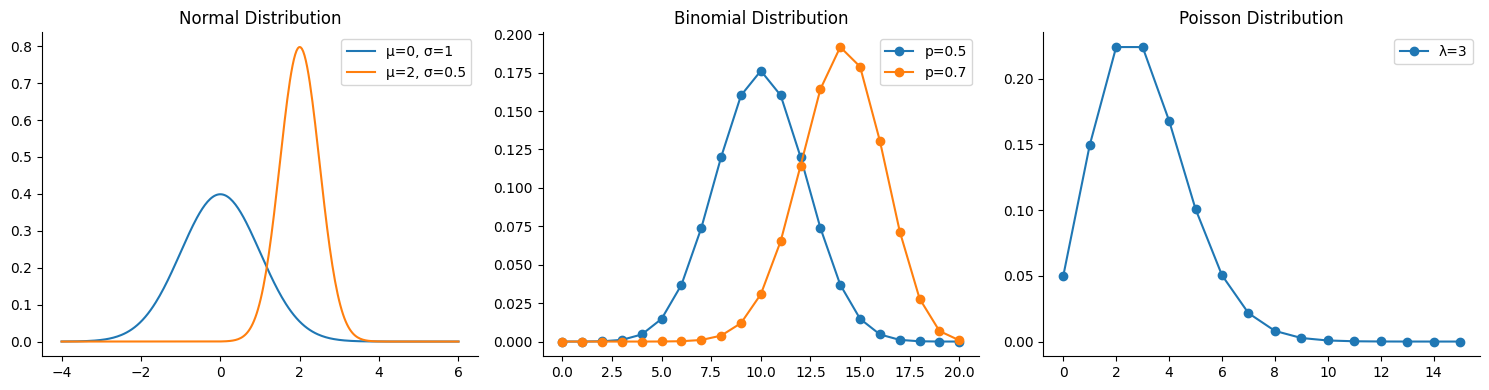

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ── Normal ──────────────────────────────────────────────────────────────────
x = np.linspace(-4, 6, 300)
# Plot two normal distributions
axes[0].plot(x, stats.norm.pdf(x, 0, 1), label='μ=0, σ=1')
axes[0].plot(x, stats.norm.pdf(x, 2, 0.5), label='μ=2, σ=0.5')

# ML use case: feature distributions in datasets
axes[0].legend()
axes[0].set_title('Normal Distribution')

# ── Binomial ────────────────────────────────────────────────────────────────
k = np.arange(0, 21)
# Plot binomial PMFs
axes[1].plot(k, stats.binom.pmf(k, 20, 0.5), 'o-', label='p=0.5')
axes[1].plot(k, stats.binom.pmf(k, 20, 0.7), 'o-', label='p=0.7')

# ML use case: probability of success/failure events

axes[1].legend()
axes[1].set_title('Binomial Distribution')

# ── Poisson ─────────────────────────────────────────────────────────────────
k2 = np.arange(0, 16)
# Plot Poisson PMF
axes[2].plot(k2, stats.poisson.pmf(k2, 3), 'o-', label='λ=3')
# ML use case: event counts over time
axes[2].legend()
axes[2].set_title('Poisson Distribution')

plt.tight_layout(); plt.show()

# Explanation

In this part different probability distributions are plotted.

For normal distribution:

```python
stats.norm.pdf()
```

is used to create bell-shaped curves.

One curve has:
- mean = `0`
- standard deviation = `1`

Second curve has:
- mean = `2`
- standard deviation = `0.5`

Smaller standard deviation makes curve more narrow.

Then binomial distribution is plotted using:

```python
stats.binom.pmf()
```

This distribution is used when there are fixed number of trials like coin tosses.

Different probability values (`p=0.5` and `p=0.7`) change the shape of graph.

After that Poisson distribution is plotted.

```python
stats.poisson.pmf()
```

This distribution is used for counting events happening in fixed interval.

Example:
- customers arriving in shop
- calls per minute
- website requests

These distributions are used a lot in statistics, ML and data analysis.

### 6.3 Bayes' Theorem

**Scenario — Spam filter:**
- P(Spam) = 0.30 (prior)
- P("free" | Spam) = 0.80 (likelihood)
- P("free" | Not Spam) = 0.05

1. Compute P(Spam | "free") using Bayes' theorem.
2. Implement a simple `naive_bayes_predict(prior_spam, p_word_given_spam, p_word_given_ham)` that returns the posterior P(Spam | word).
3. In the markdown cell, map each term — **prior, likelihood, evidence, posterior** — to the spam example.

In [25]:
P_spam = 0.30
P_free_given_spam = 0.80
P_free_given_ham = 0.05
P_ham = 1 - P_spam

# P(free) using total probability
P_free = (
    P_free_given_spam * P_spam
    +
    P_free_given_ham * P_ham
)
# Bayes theorem
P_spam_given_free = (
    P_free_given_spam * P_spam
) / P_free


print(f"P('free'): {P_free:.4f}")
print(f"P(Spam | 'free'): {P_spam_given_free:.4f}")


def naive_bayes_predict(prior_spam, p_word_given_spam, p_word_given_ham):
    p_ham = 1 - prior_spam
    p_word = (
        p_word_given_spam * prior_spam
        +
        p_word_given_ham * p_ham
    )
    posterior = (
        p_word_given_spam * prior_spam
    ) / p_word

    return posterior


pred = naive_bayes_predict(0.30, 0.80, 0.05)
assert abs(pred - P_spam_given_free) < 1e-9
print(f"naive_bayes_predict: {pred:.4f}")
print("6.3 passed ✓")

P('free'): 0.2750
P(Spam | 'free'): 0.8727
naive_bayes_predict: 0.8727
6.3 passed ✓


# Explanation

In this example Bayes theorem is used for spam filtering.

Here:
- `P(Spam)` means prior probability of spam mail
- `P("free" | Spam)` means probability that spam mail contains word `"free"`
- `P("free" | Ham)` means normal mail contains word `"free"`

First total probability of word `"free"` is calculated.

```python
P(free)
```

This combines both:
- spam emails
- non-spam emails

Then Bayes theorem is applied.

```python
P(Spam | "free")
```

This tells probability that email is spam if word `"free"` is present.

After that a small Naive Bayes prediction function is created.

It returns spam probability using:
- prior
- likelihood
- and evidence

Naive Bayes is commonly used in:
- spam filtering
- text classification
- sentiment analysis
- and email detection systems.

# Bayes Term Mapping (6.3)

| Term | Formula | In this example |
|---|---|---|
| Prior | P(Spam) | Probability that email is spam before seeing word |
| Likelihood | P(word \| Spam) | Probability of word `"free"` appearing in spam |
| Evidence | P(word) | Overall probability of word `"free"` |
| Posterior | P(Spam \| word) | Final spam probability after seeing word `"free"` |

### 6.4 Central Limit Theorem

1. Define a population following an **exponential distribution** (λ=1, size=100,000).
2. Repeatedly draw samples of size `n=30` and record their means — do this 5,000 times.
3. Plot the histogram of sample means.
4. Overlay the **theoretical normal distribution** predicted by the CLT: μ = population mean, σ = population_std / sqrt(n).
5. Run a KS test to confirm the distribution of sample means is approximately normal.

Population mean: 1.0005, Population std: 1.0006
Sample means mean: 0.9971, std: 0.1828
CLT predicted std: 0.1827


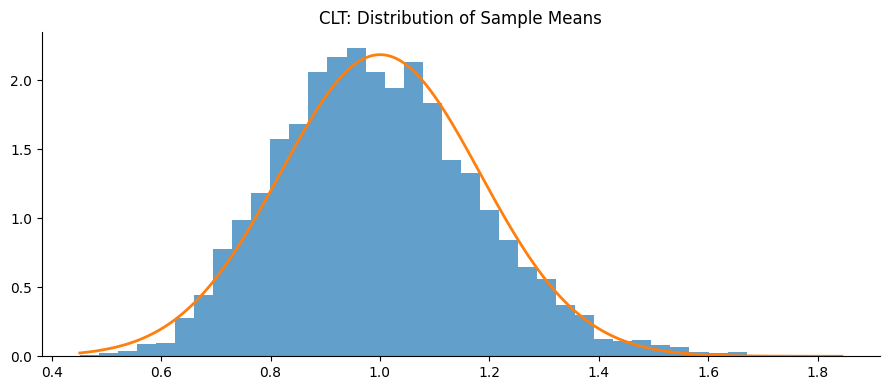

KS test p-value: 0.0000 → Approximately normal? False


In [26]:
np.random.seed(7)
population = np.random.exponential(scale=1.0, size=100_000)

n_samples = 5000
sample_size = 30
# Generate sample means
sample_means = np.array([
    np.random.choice(population, sample_size).mean()
    for _ in range(n_samples)
])

pop_mean = population.mean()
pop_std = population.std()

# Predicted std using CLT
clt_std = pop_std / np.sqrt(sample_size)

print(f"Population mean: {pop_mean:.4f}, Population std: {pop_std:.4f}")
print(f"Sample means mean: {sample_means.mean():.4f}, std: {sample_means.std():.4f}")
print(f"CLT predicted std: {clt_std:.4f}")

# Plot
fig, ax = plt.subplots()
# Histogram of sample means
ax.hist(sample_means, bins=40, density=True, alpha=0.7)
# Theoretical normal distribution
x = np.linspace(
    sample_means.min(),
    sample_means.max(),
    300
)
ax.plot(
    x,
    stats.norm.pdf(x, pop_mean, clt_std),
    linewidth=2
)
ax.set_title('CLT: Distribution of Sample Means')
plt.tight_layout()
plt.show()

# KS test
ks_result = stats.kstest(sample_means, 'norm', args=(pop_mean, clt_std))
print(f"KS test p-value: {ks_result.pvalue:.4f} → Approximately normal? {ks_result.pvalue > 0.05}")

# Explanation

Here population data is created using exponential distribution.

```python
np.random.exponential()
```

Exponential distribution itself is not normal.

Then 5000 random samples are taken.

Each sample has size `30`.

For every sample, mean value is calculated and stored.

```python
sample.mean()
```

After many samples, distribution of sample means starts looking normal.

This is the main idea of Central Limit Theorem.

Then theoretical normal curve is plotted using:

```python
stats.norm.pdf()
```

Standard deviation predicted by CLT is:

```python
population_std / √n
```

At the end KS test is used to check whether sample means are approximately normal or not.

Even if original population is not normal, sample means become close to normal when sample size becomes large enough.

# CLT Reflection (6.4)

Central Limit Theorem is important because many real datasets are not perfectly normal.

But when we take enough samples, the sample means behave almost like normal distribution.

This helps many statistical methods work properly, especially hypothesis testing and confidence intervals.

---
## 🏁 Submission Checklist

Before submitting, verify:

- [✔️ ] All `assert` blocks pass without errors
- [ ✔️] All `# YOUR CODE HERE` cells are filled
- [✔️ ] All markdown reflection cells are filled in your own words
- [✔️ ] All plots render with labels and titles
- [✔️ ] Notebook runs cleanly from top to bottom (`Kernel → Restart & Run All`)

**Save as:** `week1_<your_name>.ipynb`